In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class PMT:
  def __init__(self, dt, t_max, V_0 = 0):
    self.t = np.arange(0, t_max, dt)
    self.V = np.zeros_like(self.t, dtype=float) + V_0

  def pulse(self, t_0, q=1, sigma=3.0, tau=5.0, R_tilde=1.0):
    t_tilde = (sigma ** 2) / tau
    C = np.exp(-0.5 * (sigma / tau) ** 2)

    t_shifted = self.t - t_0

    gauss_mask = t_shifted <= t_tilde
    self.V[gauss_mask] += q * R_tilde * np.exp(-0.5 * (t_shifted[gauss_mask] / sigma) ** 2)

    exp_mask = t_shifted > t_tilde
    self.V[exp_mask] += (q * R_tilde / C) * np.exp(-t_shifted[exp_mask] / tau)

    return self

  def noise(self, snr_db):
    # Noise from SNR, assuming 1Vpp sine wave
    p_signal = (0.5 ** 2) / 2
    snr_linear = 10 ** (snr_db / 10.0)
    p_noise = p_signal / snr_linear
    noise_std = np.sqrt(p_noise)
    rng = np.random.default_rng()
    white_noise = rng.normal(loc=0.0, scale=noise_std, size=self.V.shape)
    self.V += white_noise
    return self

  def digitize(self, num_bits=12):
        max_int = (1 << num_bits) - 1
        v_clipped = np.clip(self.V, 0, 1)
        v_scaled = np.round(v_clipped * max_int)
        if num_bits <= 8:
            dtype = np.uint8
        elif num_bits <= 16:
            dtype = np.uint16
        elif num_bits <= 32:
            dtype = np.uint32
        self.V = v_scaled.astype(dtype)
        return self

  def get(self):
    return self.t, self.V


In [3]:
from collections import deque

class CFD:
  def __init__(self, data_mux, delay_samples, scale):
    self.data_mux = data_mux
    self.delay = delay_samples
    self.scale = scale

    self.prev_iter_data = np.zeros(self.delay)
    self.buff = np.zeros(self.data_mux + self.delay)


  def clk(self, input): # function executed for each clock cycle
    self.buff[:self.delay] = self.prev_iter_data
    self.buff[self.delay:] = input
    self.prev_iter_data = self.buff[self.data_mux:]
    top = self.scale * self.buff[:self.data_mux]
    bottom = self.buff[self.delay:]

    return top - bottom

In [4]:
class ZeroCrossingDetector:
  def __init__(self, data_mux, cfd_threshold, cfd_zero):
    self.cfd_threshold = cfd_threshold
    self.cfd_zero = cfd_zero
    self.data_mux = data_mux
    self.prev_state = 0 # 0 - negative, 1 - positive

  def clk(self, input): # function executed for each clock cycle
    state = np.zeros(self.data_mux + 1)
    state[0] = self.prev_state
    for i, v in enumerate(input):
      if v > self.cfd_zero + self.cfd_threshold:
        state[i+1] = 1
      elif v < self.cfd_zero - self.cfd_threshold:
        state[i+1] = 0
      else:
        state[i+1] = state[i]
    self.prev_state = state[-1]

    out = np.zeros(self.data_mux)
    for i in range(self.data_mux):
      if state[i+1] == 1 and state[i] == 0:
        out[i] = 1
    return out

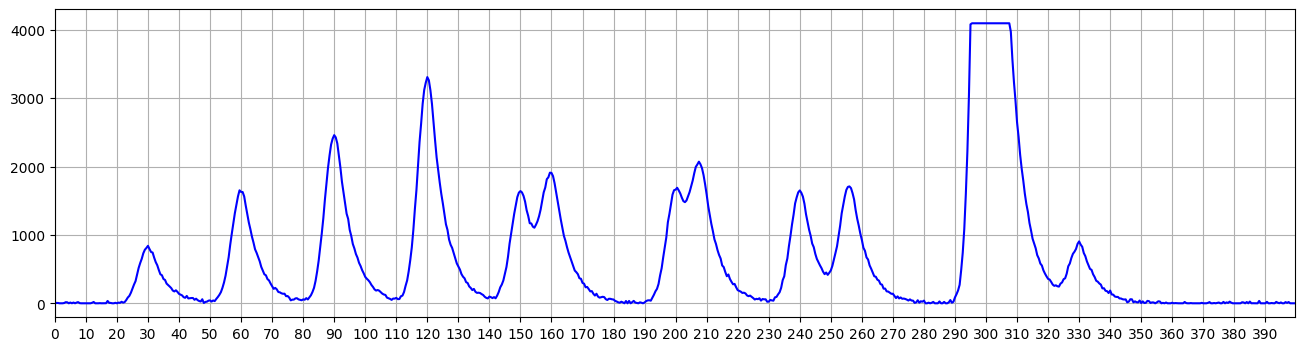

In [5]:
# Impulse generation
DT = 0.5 # 2GHz
t, V = PMT(DT, 400) \
  .pulse(30, q=0.2) \
  .pulse(60, q=0.4) \
  .pulse(90, q=0.6) \
  .pulse(120, q=0.8) \
  .pulse(150, q=0.4) \
  .pulse(160, q=0.4) \
  .pulse(200, q=0.4) \
  .pulse(208, q=0.4) \
  .pulse(240, q=0.4) \
  .pulse(256, q=0.4) \
  .pulse(300, q=4.0) \
  .pulse(330, q=0.2) \
  .noise(40) \
  .digitize() \
  .get()

plt.figure(figsize=(16, 4))
plt.grid(True)
plt.xticks(np.arange(np.min(t), np.max(t), 10))
plt.plot(t, V, label='in', color='blue')
plt.xlim(np.min(t), np.max(t))
plt.show()

In [6]:
from ipywidgets import interactive, BoundedIntText, BoundedFloatText

DATA_MUX = 16

V = V[: (len(V) // DATA_MUX) * DATA_MUX]
t = t[: (len(t) // DATA_MUX) * DATA_MUX]

def update_plot(delay, scale, cfd_threshold, cfd_zero):
    cfd = CFD(data_mux=DATA_MUX, delay_samples=delay, scale=scale)
    zcd = ZeroCrossingDetector(data_mux=DATA_MUX, cfd_threshold=cfd_threshold, cfd_zero=cfd_zero)

    sum_vals = []
    pulse_vals = []

    v_iter = iter(V)
    for v_packet in zip(*[v_iter] * DATA_MUX):
        cfd_out = cfd.clk(v_packet)
        zcd_out = zcd.clk(cfd_out)
        sum_vals.extend(cfd_out)
        pulse_vals.extend(zcd_out)

    timestamps = []
    for timestamp, pulse_detected in zip(t, pulse_vals):
        if pulse_detected == 1:
            timestamps.append(timestamp)

    plt.figure(figsize=(16, 4))

    for ts in timestamps:
        plt.axvline(x=ts, color='green')

    plt.axhspan(ymin=cfd_zero-cfd_threshold, ymax=cfd_zero+cfd_threshold,
                color='r', alpha=0.1, zorder=0, label='CFD threshold range')
    plt.xticks(np.arange(0, np.max(t), 25))
    plt.xlim(np.min(t), np.max(t))
    plt.ylim(-512, 4096)
    plt.grid(True)

    plt.plot(t, V, label='in', color='blue')
    plt.plot(t, sum_vals, label='sum', color='purple', linestyle='--')
    plt.legend(loc='upper right')
    plt.show()

    return timestamps

DELAY=3
SCALE=1 + 0.125 * 3
CFD_THRESHOLD=50
CFD_ZERO=0

interactive_plot = interactive(
    update_plot,
    delay=BoundedIntText(min=1, max=20, step=1, value=DELAY, description='DELAY'),
    scale=BoundedFloatText(min=0.5, max=5.0, step=0.125, value=SCALE, description='SCALE'),
    cfd_threshold=BoundedIntText(min=0, max=512, step=1, value=CFD_THRESHOLD, description='CFD_THRESHOLD'),
    cfd_zero=BoundedIntText(min=-256, max=256, step=1, value=CFD_ZERO, description='CFD_ZERO')
)
display(interactive_plot)

interactive(children=(BoundedIntText(value=3, description='DELAY', max=20, min=1), BoundedFloatText(value=1.37…

In [7]:
# Verify the fraction at which the CFD was triggered
for ts in interactive_plot.result:
  idx = int(ts / DT)
  detected_level = V[idx]
  peak_level = np.max(V[idx:idx+8]) # Look for peak 8 samples after detection
  fraction = detected_level / peak_level
  print(f"{fraction:.3f}")


0.963
1.000
0.944
0.943
0.986
0.979
0.983
0.970
1.000
0.878


In [10]:
# Export input data to CSV
# for v in V:
#   print(v)